In [2]:

from google.colab import files
uploaded = files.upload()


Saving dataset.arff to dataset.arff


In [5]:
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff('dataset.arff')
df = pd.DataFrame(data)

df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

In [ ]:
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

/tmp/ipykernel_1272/2692274460.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


In [ ]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
df.columns

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [ ]:
X = df.drop('Result', axis=1)  # input
y = df['Result']               # label

In [ ]:
df['HTTPS_token'] = pd.to_numeric(df['HTTPS_token'], errors='coerce')
df['Result'] = pd.to_numeric(df['Result'], errors='coerce')

In [ ]:
df['Result'].head()

,Result
0,-1
1,-1
2,-1
3,-1
4,1


In [ ]:
df['Result'] = pd.to_numeric(df['Result'], errors='coerce')

In [ ]:
df['Result'].value_counts()

,count
Result,
1,6157
-1,4898


/tmp/ipykernel_11982/1724756952.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


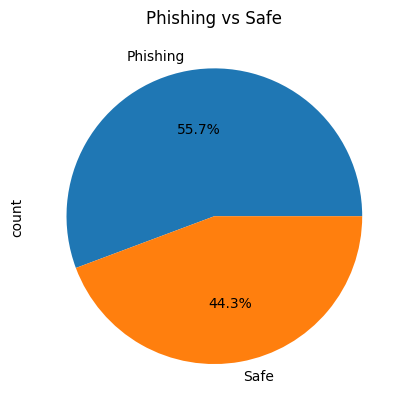


==== HTTPS_token ====
Result        Phishing       Safe
HTTPS_token                      
-1           60.189310  39.810690
 1           54.822335  45.177665


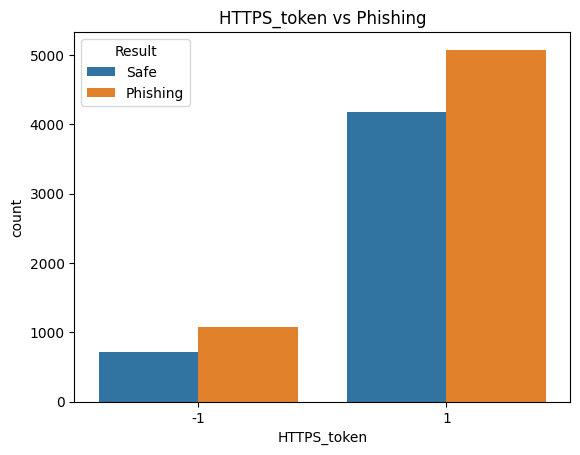


==== having_IP_Address ====
Result              Phishing       Safe
having_IP_Address                      
-1                 49.222252  50.777748
 1                 59.074635  40.925365


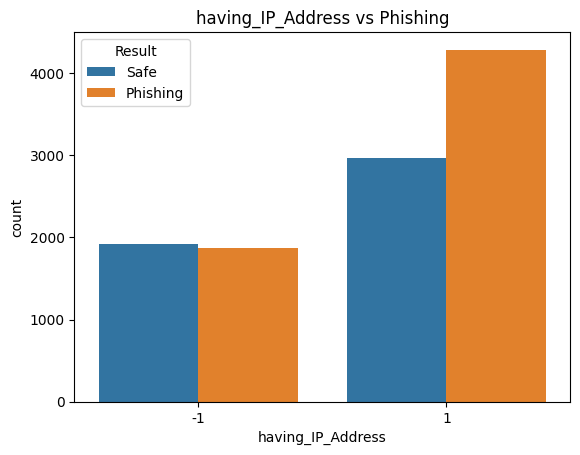


==== URL_Length ====
Result       Phishing       Safe
URL_Length                      
-1          54.475446  45.524554
 0          38.518519  61.481481
 1          62.448980  37.551020


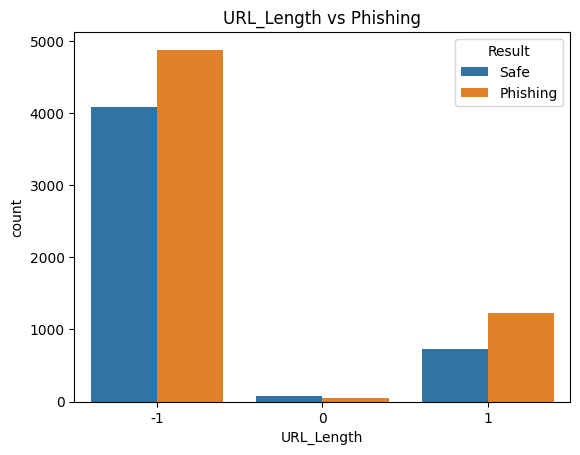


==== SSLfinal_State ====
Result           Phishing       Safe
SSLfinal_State                      
-1              14.225471  85.774529
 0               1.799486  98.200514
 1              88.927500  11.072500


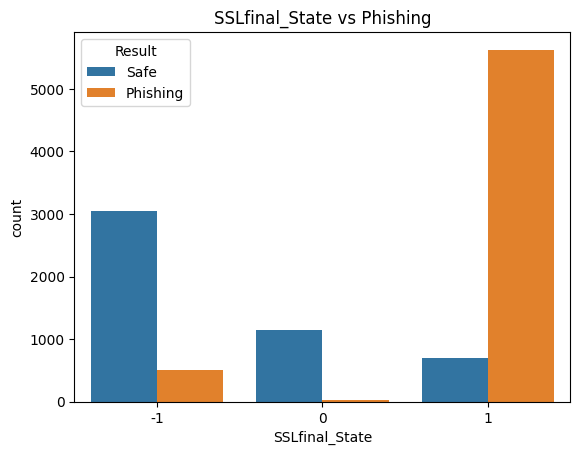


==== Prefix_Suffix ====
Result           Phishing       Safe
Prefix_Suffix                       
-1              48.925965  51.074035
 1             100.000000   0.000000


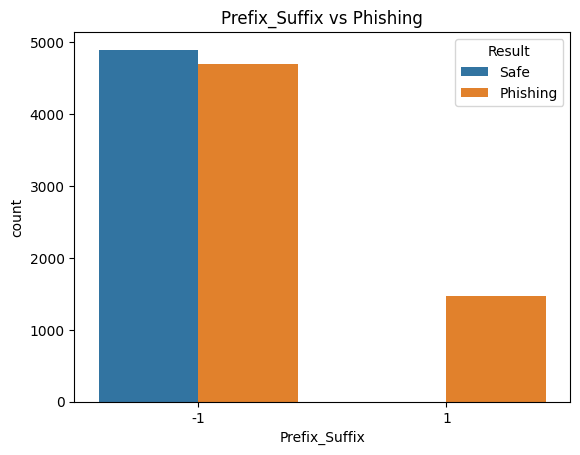

In [ ]:
from scipy.io import arff
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data, meta = arff.loadarff('dataset.arff')
df = pd.DataFrame(data)

# Decode bytes
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Map label
df['Result'] = df['Result'].map({1: 'Phishing', -1: 'Safe'})

# Pie chart
df['Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Phishing vs Safe")
plt.show()

# Features
features = [
    'HTTPS_token',
    'having_IP_Address',
    'URL_Length',
    'SSLfinal_State',
    'Prefix_Suffix'
]

for col in features:
    print(f"\n==== {col} ====")
    print(pd.crosstab(df[col], df['Result'], normalize='index')*100)

    sns.countplot(x=col, hue='Result', data=df)
    plt.title(f"{col} vs Phishing")
    plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# Tách input và label
X = df.drop('Result', axis=1)
y = df['Result']

# Chia dữ liệu 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Tạo model
dt = DecisionTreeClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

y_pred_knn = knn.predict(X_test_scaled)
# Đánh giá
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9574853007688828


In [17]:
from sklearn.metrics import classification_report

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

=== KNN ===
              precision    recall  f1-score   support

          -1       0.94      0.92      0.93       956
           1       0.94      0.96      0.95      1255

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211

=== Decision Tree ===
              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       956
           1       0.96      0.96      0.96      1255

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211

